# Segmentación de clientes con aprendizaje no supervisado

En este notebook construimos un flujo completo de **preprocesamiento**, reducción de dimensionalidad (PCA y t-SNE) y **clusterización** (K-Means, DBSCAN y agrupamiento jerárquico) para un problema de segmentación de clientes.

## 1. Imports y carga robusta de datos

1. Importamos todas las librerías necesarias.
2. Definimos la carpeta de datos y verificamos que existan `Train.csv` y `Test.csv`.
3. Cargamos los archivos y mostramos su tamaño para confirmar que todo esté correcto.

In [1]:
# ============================
# 1. IMPORTS Y CARGA DE DATOS
# ============================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1.1. Configuración visual
sns.set(style="whitegrid", context="notebook")

# 1.2. Rutas de datos
DATA_DIR = "."  # puedes cambiar esta ruta si tus CSV están en otra carpeta
train_path = os.path.join(DATA_DIR, "Train.csv")
test_path  = os.path.join(DATA_DIR, "Test.csv")

if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError("No se encontraron Train.csv o Test.csv en la carpeta indicada.")

# 1.3. Carga de datos
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Shapes - Train:", train.shape, " Test:", test.shape)
display(train.head())


Shapes - Train: (8068, 11)  Test: (2627, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


## 2. Selección de columnas y preprocesamiento

1. Definimos la columna objetivo (`Segmentation`) y la columna de identificación (`ID`).
2. Detectamos automáticamente qué columnas son numéricas y cuáles categóricas.
3. Construimos un `ColumnTransformer` que aplica un pipeline distinto a numéricas y categóricas.
4. Ajustamos el preprocesador con `train` y transformamos tanto `train` como `test`.

In [2]:
# ==================================
# 2. SELECCIÓN DE COLUMNAS & PIPELINE
# ==================================

target_col = "Segmentation"
id_col = "ID"

# 2.1. Columnas de características (excluimos la etiqueta del train)
feature_cols = [c for c in train.columns if c not in [target_col]]

# 2.2. Detección de numéricas y categóricas
num_cols = train[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train[feature_cols].select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# 2.3. Pipelines por tipo de dato
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 2.4. Preprocesador combinado
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# 2.5. Separar X_train, y_train y X_test
X_train = train[feature_cols].copy()
y_train = train[target_col].copy()
X_test  = test[feature_cols].copy()

# 2.6. Ajustar y transformar
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("Shape X_train_proc:", X_train_proc.shape)
print("Shape X_test_proc: ", X_test_proc.shape)


Numéricas: ['ID', 'Age', 'Work_Experience', 'Family_Size']
Categóricas: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
Shape X_train_proc: (8068, 29)
Shape X_test_proc:  (2627, 29)


## 3. PCA: reducción lineal de dimensionalidad

1. Aplicamos PCA con 2 componentes principales para visualización.
2. Calculamos la proporción de varianza explicada por cada componente.
3. Generamos un scatter plot de PC1 vs PC2 coloreado según la etiqueta original `Segmentation`.

Varianza explicada por PC1 y PC2: [0.21933291 0.15156702]


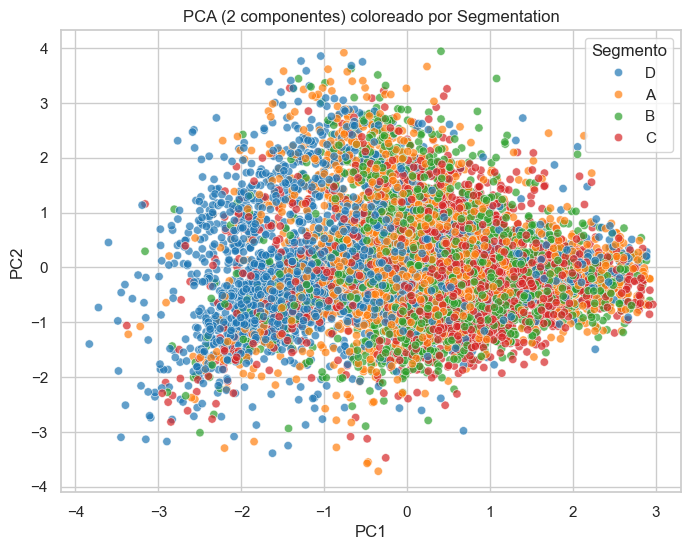

In [3]:
# ==========================
# 3. PCA (REDUCCIÓN LINEAL)
# ==========================

# 3.1. Convertimos a array denso si es matriz dispersa
X_for_pca = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc

# 3.2. Ajustamos PCA para 2 componentes
pca_2 = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2.fit_transform(X_for_pca)

print("Varianza explicada por PC1 y PC2:", pca_2.explained_variance_ratio_)

# 3.3. DataFrame para visualizar
pca_df = pd.DataFrame({
    "PC1": X_train_pca2[:, 0],
    "PC2": X_train_pca2[:, 1],
    "Segmentation": y_train.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Segmentation",
    palette="tab10",
    alpha=0.7
)
plt.title("PCA (2 componentes) coloreado por Segmentation")
plt.legend(title="Segmento")
plt.show()


## 4. t-SNE: reducción no lineal de dimensionalidad

1. t-SNE proyecta los datos a 2D preservando vecindarios locales.
2. Usamos una muestra si el dataset es grande para evitar tiempos de cómputo muy altos.
3. Visualizamos el mapa t-SNE coloreado por `Segmentation`.

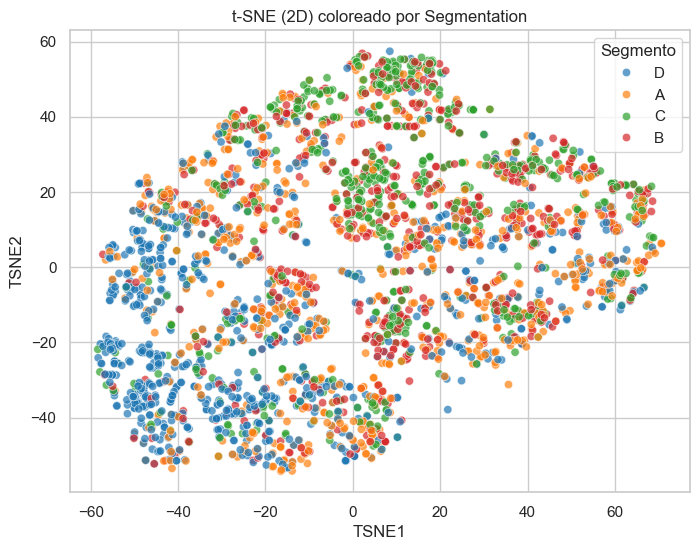

In [4]:
# ==========================
# 4. t-SNE (REDUCCIÓN NO LINEAL)
# ==========================

X_for_tsne = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc

n_samples_tsne = 3000  # ajusta este valor si es necesario

if X_for_tsne.shape[0] > n_samples_tsne:
    rng = np.random.RandomState(42)
    idx_sample = rng.choice(X_for_tsne.shape[0], n_samples_tsne, replace=False)
    X_tsne_input = X_for_tsne[idx_sample]
    y_tsne = y_train.iloc[idx_sample]
else:
    X_tsne_input = X_for_tsne
    y_tsne = y_train

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)
X_train_tsne2 = tsne.fit_transform(X_tsne_input)

tsne_df = pd.DataFrame({
    "TSNE1": X_train_tsne2[:, 0],
    "TSNE2": X_train_tsne2[:, 1],
    "Segmentation": y_tsne.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df,
    x="TSNE1", y="TSNE2",
    hue="Segmentation",
    palette="tab10",
    alpha=0.7
)
plt.title("t-SNE (2D) coloreado por Segmentation")
plt.legend(title="Segmento")
plt.show()


## 5. Clustering: K-Means, DBSCAN y agrupamiento jerárquico

1. Aplicamos K-Means con un número fijo de clústeres (por defecto 4).
2. Aplicamos DBSCAN para detectar clústeres de densidad y ruido.
3. Aplicamos agrupamiento jerárquico aglomerativo.
4. Calculamos la puntuación de silueta para cada método y creamos una tabla resumen.

In [5]:
# =========================================
# 5. CLUSTERING: K-MEANS, DBSCAN, JERÁRQUICO
# =========================================

# 5.0. Matriz para clustering (array denso si es necesario)
X_clust = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc

# 5.1. K-Means (ejemplo k=4)
k_opt = 4  # puedes ajustar este valor con método del codo o silueta adicional
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_clust)

sil_kmeans = silhouette_score(X_clust, labels_kmeans)
print(f"Silueta K-Means (k={k_opt}): {sil_kmeans:.3f}")

# 5.2. DBSCAN
# Nota: los parámetros eps y min_samples deben ajustarse empíricamente.
dbscan = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_clust)

mask_no_ruido = labels_dbscan != -1
n_ruido = (labels_dbscan == -1).sum()
clusters_validos = labels_dbscan[mask_no_ruido]

if mask_no_ruido.sum() > 1 and len(set(clusters_validos)) > 1:
    sil_dbscan = silhouette_score(X_clust[mask_no_ruido], clusters_validos)
else:
    sil_dbscan = np.nan

n_clusters_dbscan = len(set(clusters_validos))

print(f"DBSCAN - clústeres efectivos: {n_clusters_dbscan}, ruido: {n_ruido}, silueta (sin ruido): {sil_dbscan}")

# 5.3. Agrupamiento jerárquico
hier = AgglomerativeClustering(n_clusters=k_opt)
labels_hier = hier.fit_predict(X_clust)

sil_hier = silhouette_score(X_clust, labels_hier)
print(f"Silueta Jerárquico (k={k_opt}): {sil_hier:.3f}")

# 5.4. Resumen en tabla
resumen = pd.DataFrame({
    "Algoritmo": ["K-Means", "DBSCAN", "Jerárquico"],
    "N_clústeres_efectivos": [len(set(labels_kmeans)), n_clusters_dbscan, len(set(labels_hier))],
    "Silueta": [sil_kmeans, sil_dbscan, sil_hier],
    "N_ruido": [0, n_ruido, 0]
})

display(resumen)


Silueta K-Means (k=4): 0.138
DBSCAN - clústeres efectivos: 1, ruido: 1387, silueta (sin ruido): nan
Silueta Jerárquico (k=4): 0.098


,Algoritmo,N_clústeres_efectivos,Silueta,N_ruido
0,K-Means,4,0.137779,0
1,DBSCAN,1,NaN,1387
2,Jerárquico,4,0.097865,0


## 6. Visualización de clústeres en el plano PCA

1. Usamos las dos componentes principales de PCA como ejes X e Y.
2. Pintamos los puntos coloreados por el clúster asignado por K-Means.
3. Repetimos la visualización para el agrupamiento jerárquico.

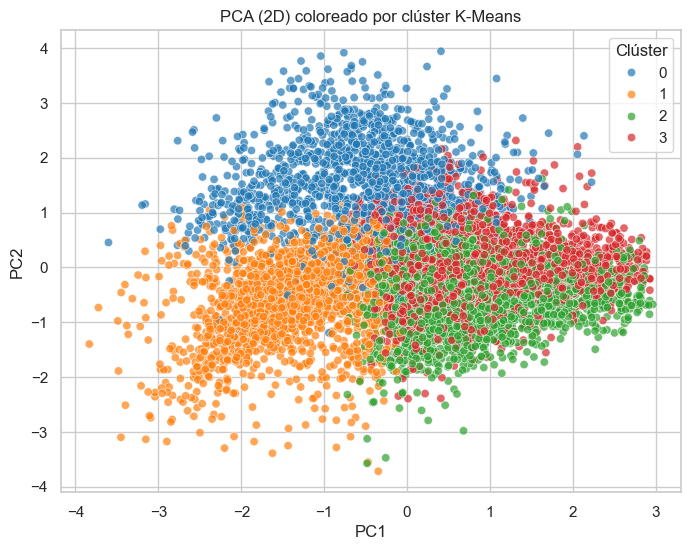

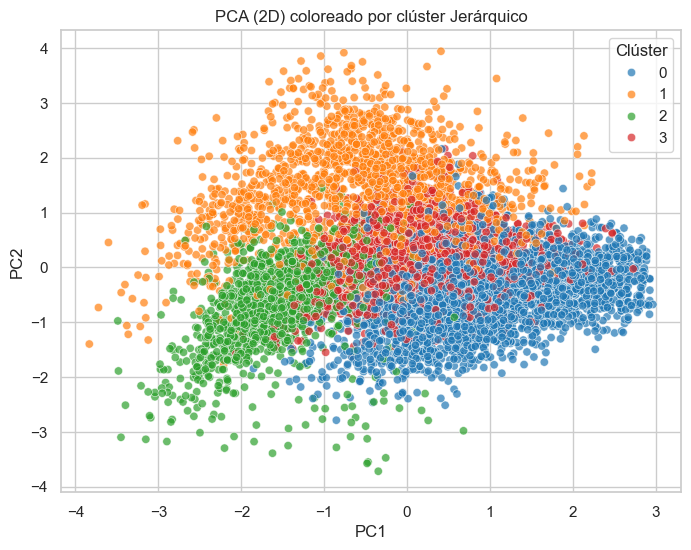

In [6]:
# ====================================
# 6. VISUALIZACIÓN DE CLÚSTERES EN PCA
# ====================================

pca_plot_df = pd.DataFrame({
    "PC1": X_train_pca2[:, 0],
    "PC2": X_train_pca2[:, 1],
    "KMeans": labels_kmeans,
    "Hier": labels_hier
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1", y="PC2",
    hue="KMeans",
    palette="tab10",
    alpha=0.7
)
plt.title("PCA (2D) coloreado por clúster K-Means")
plt.legend(title="Clúster")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1", y="PC2",
    hue="Hier",
    palette="tab10",
    alpha=0.7
)
plt.title("PCA (2D) coloreado por clúster Jerárquico")
plt.legend(title="Clúster")
plt.show()


## 7. Aplicar el modelo al conjunto Test y exportar resultados

1. Reentrenamos K-Means con todo el conjunto de entrenamiento preprocesado.
2. Transformamos el conjunto de Test con el mismo preprocesador.
3. Asignamos un clúster a cada cliente del Test.
4. Guardamos un archivo CSV con `ID` y `Cluster` para análisis posterior.

In [7]:
# ==========================================
# 7. APLICAR K-MEANS A TEST Y EXPORT RESULTADO
# ==========================================

# 7.1. Reentrenar K-Means en todo X_train_proc
X_clust = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc
k_final = 4
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
kmeans_final.fit(X_clust)

# 7.2. Transformar Test y predecir clúster
X_test_clust = X_test_proc.toarray() if hasattr(X_test_proc, "toarray") else X_test_proc
labels_test = kmeans_final.predict(X_test_clust)

# 7.3. Crear DataFrame de salida
submission = pd.DataFrame({
    id_col: test[id_col],
    "Cluster": labels_test
})

display(submission.head())

# 7.4. Guardar a CSV
output_path = os.path.join(DATA_DIR, "segmentacion_clientes_clusters.csv")
submission.to_csv(output_path, index=False)
print("Archivo de clusters guardado en:", output_path)


,ID,Cluster
0,458989,3
1,458994,0
2,458996,3
3,459000,0
4,459001,1


Archivo de clusters guardado en: .\segmentacion_clientes_clusters.csv
